# Sleep Disorder Prediction System 

## Problem
Sleep disorders, such as **sleep apnea** and **insomnia**, are often hard to detect and can have negative effects on health and overall well-being.  
Early detection is crucial for preventing long-term health issues and improving quality of life.

## Goal
The goal of this project is to build a **machine learning classification model** that can:
- Detect sleep disorders early  
- Alert users to take preventive action  
- Identify key risk factors contributing to sleep problems

## Key Features & ML Workflow

- **End-to-End ML Pipeline** – complete workflow from data input to deployed prediction system  

- **Data Collection & Input** – users provide health and lifestyle data (blood pressure, heart rate, physical activity, etc.)  

- **Data Preprocessing** – handling missing values, scaling, and encoding categorical variables  

- **Feature Selection & Engineering** – selecting relevant features and creating derived variables to improve model performance  

- **Model Training & Comparison** – multiple machine learning models tested and compared  

- **Hyperparameter Tuning** – optimizing model performance using techniques such as Grid Search / Random Search  

- **Final Model (XGBoost)** – selected based on best performance  

- **Model Evaluation** – performance measured using accuracy, confusion matrix, and classification report  

- **Model Interpretability** – SHAP values used to explain feature importance and model decisions  

- **Deployment** – model exposed via a **REST API endpoint**  

- **User Interaction** – simple frontend allows users to input data and receive **real-time predictions**  

- **Live Access** – deployed on **Render** for full end-to-end accessibility

## Real-World Application
The system can be integrated into **health platforms or wearable apps**  providing **early warnings for users about potential sleep issues**.  
Users can take preventive measures such as increasing physical activity, monitoring blood pressure, or consulting a healthcare professional.

# 🧠 Sleep Disorder Prediction System

## 📌 Problem
Sleep disorders, such as **sleep apnea** and **insomnia**, are often hard to detect and can have **negative effects on health and overall well-being**.  
Early detection is crucial for preventing long-term health issues and improving quality of life.

## 🎯 Goal
The goal of this project is to build a **machine learning classification model** that can:
- **Detect sleep disorders** early  
- **Alert users** to take preventive action  
- **Identify key risk factors** contributing to sleep problems

## 🚀 Key Features
- **XGBoost model** for high accuracy in classification  
- **Model interpretability** using SHAP values  
- **REST API endpoint** for predictions  
- **Simple frontend** for user input and real-time results  
- **Deployed on Render** for live access  

## 🌐 Real-World Application
The system can be integrated into **health platforms or wearable apps** (e.g., :contentReference[oaicite:0]{index=0}), providing **early warnings for users about potential sleep issues**.  
Users can take preventive measures such as increasing physical activity, monitoring blood pressure, or consulting a healthcare professional.

## ⚠️ Limitations
- The model is a **support tool**, not a replacement for professional medical diagnosis  
- Predictions are based on the **available dataset** and may require further validation on larger populations  
- Continuous monitoring and model updates are recommended for accuracy

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
import joblib
import shap

In [99]:
#Load dataset from the file
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
print(df)

     Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6   Overweight   
1                

In [100]:
df.describe

<bound method NDFrame.describe of      Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6

In [101]:
df.info

<bound method DataFrame.info of      Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6  

In [102]:
# Generate summary statistics for each feature:
summary_values = {}
for col in df.columns:
   summary = df[col].value_counts(dropna=False)
   percent = df[col].value_counts(normalize=True, dropna=False) * 100 #percentage distribution (including missing values)
   summary_values[col] = {"values": summary, "percent": percent} 
print(summary_values)

{'Person ID': {'values': Person ID
1      1
2      1
3      1
4      1
5      1
      ..
370    1
371    1
372    1
373    1
374    1
Name: count, Length: 374, dtype: int64, 'percent': Person ID
1      0.26738
2      0.26738
3      0.26738
4      0.26738
5      0.26738
        ...   
370    0.26738
371    0.26738
372    0.26738
373    0.26738
374    0.26738
Name: proportion, Length: 374, dtype: float64}, 'Gender': {'values': Gender
Male      189
Female    185
Name: count, dtype: int64, 'percent': Gender
Male      50.534759
Female    49.465241
Name: proportion, dtype: float64}, 'Age': {'values': Age
43    34
44    30
37    20
38    20
50    20
31    18
32    17
53    17
59    16
39    15
45    14
29    13
30    13
33    13
35    12
36    12
41    12
49    11
42     9
52     9
57     9
51     8
54     7
58     6
28     5
40     4
48     3
34     2
55     2
56     2
27     1
Name: count, dtype: int64, 'percent': Age
43    9.090909
44    8.021390
37    5.347594
38    5.347594
50    5.34759

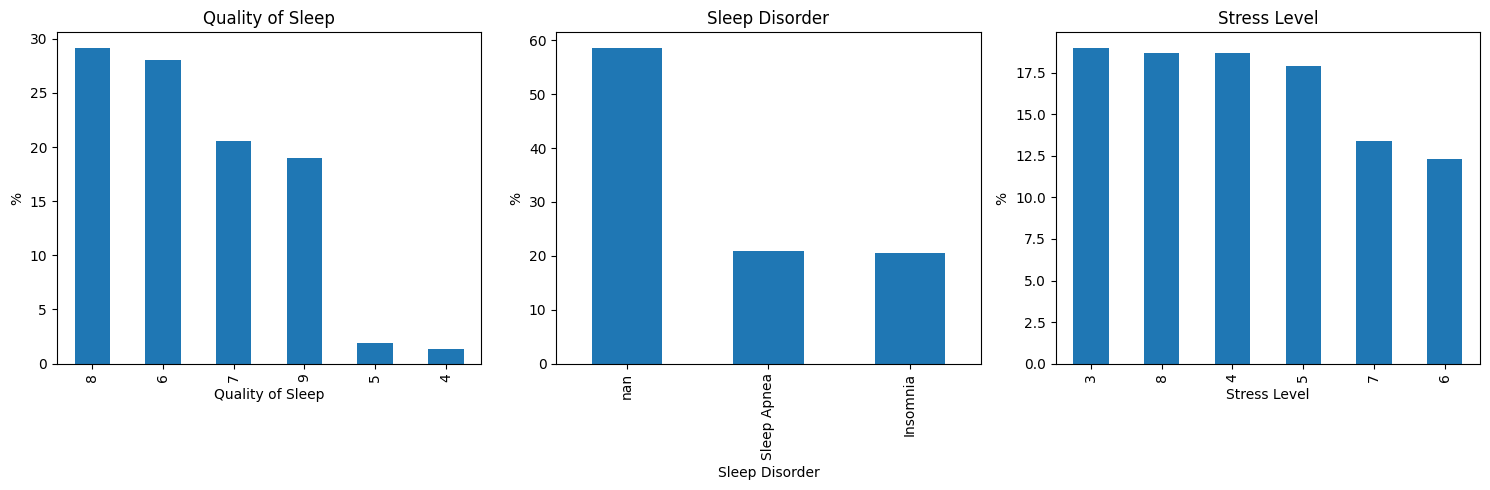

In [103]:
# Analyze categorical feature distributions to:
# - detect class imbalance
# - understand feature variability
# - identify potentially informative features for modeling
categorical_cols = ["Quality of Sleep", "Sleep Disorder", "Stress Level"]

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15,5))

for ax, col in zip(axes, categorical_cols):
    summary_values[col]["percent"].plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("%")
    
plt.tight_layout()
plt.show()

In [104]:
# Data preprocessing and cleaning to prepare dataset for modeling
df_ml = df.drop("Person ID", axis=1) # Remove non-informative identifier
# Standardize category naming
df_ml["BMI Category"] = df_ml["BMI Category"].replace(to_replace="Normal Weight", value="Normal")
print(df_ml["BMI Category"].value_counts())
# Split blood pressure into two numerical features
df_ml[["Systolic", "Diastolic"]] = df_ml["Blood Pressure"].str.split("/", expand=True).astype(int)
# Drop original non-numeric column
df_ml = df_ml.drop("Blood Pressure", axis=1)
print(df_ml[["Systolic", "Diastolic"]])
# Handle missing values in target-related feature
df_ml["Sleep Disorder"] = df_ml["Sleep Disorder"].fillna("None")

BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64
     Systolic  Diastolic
0         126         83
1         125         80
2         125         80
3         140         90
4         140         90
..        ...        ...
369       140         95
370       140         95
371       140         95
372       140         95
373       140         95

[374 rows x 2 columns]


In [105]:
import pandas as pd

def check_outliers_iqr(df):
    results = []

    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        results.append({
            "column": col,
            "outliers_count": len(outliers),
            "percentage": round(len(outliers) / len(df) * 100, 2)
        })

    return pd.DataFrame(results).sort_values(by="outliers_count", ascending=False)

check_outliers_iqr(df_ml)

,column,outliers_count,percentage
5,Heart Rate,15,4.01
0,Age,0,0.00
1,Sleep Duration,0,0.00
3,Physical Activity Level,0,0.00
2,Quality of Sleep,0,0.00
4,Stress Level,0,0.00
6,Daily Steps,0,0.00
7,Systolic,0,0.00
8,Diastolic,0,0.00


In [106]:
col = "Heart Rate"

Q1 = df_ml[col].quantile(0.25)
Q3 = df_ml[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_df = df_ml[(df_ml[col] < lower) | (df_ml[col] > upper)]

print(outliers_df)

     Gender  Age            Occupation  Sleep Duration  Quality of Sleep  \
3      Male   28  Sales Representative             5.9                 4   
4      Male   28  Sales Representative             5.9                 4   
5      Male   28     Software Engineer             5.9                 4   
6      Male   29               Teacher             6.3                 6   
16   Female   29                 Nurse             6.5                 5   
18   Female   29                 Nurse             6.5                 5   
80   Female   34             Scientist             5.8                 4   
81   Female   34             Scientist             5.8                 4   
93     Male   35                Lawyer             7.4                 7   
145  Female   38                Lawyer             7.4                 7   
147    Male   39              Engineer             6.5                 5   
264    Male   48                Doctor             7.3                 7   
266    Male 

In [107]:
summary_values = {}
for col in df_ml.columns:
   summary = df_ml[col].value_counts(dropna=False)
   percent = df_ml[col].value_counts(normalize=True, dropna=False) * 100 #percentage distribution (including missing values)
   summary_values[col] = {"values": summary, "percent": percent} 
print(summary_values)

{'Gender': {'values': Gender
Male      189
Female    185
Name: count, dtype: int64, 'percent': Gender
Male      50.534759
Female    49.465241
Name: proportion, dtype: float64}, 'Age': {'values': Age
43    34
44    30
37    20
38    20
50    20
31    18
32    17
53    17
59    16
39    15
45    14
29    13
30    13
33    13
35    12
36    12
41    12
49    11
42     9
52     9
57     9
51     8
54     7
58     6
28     5
40     4
48     3
34     2
55     2
56     2
27     1
Name: count, dtype: int64, 'percent': Age
43    9.090909
44    8.021390
37    5.347594
38    5.347594
50    5.347594
31    4.812834
32    4.545455
53    4.545455
59    4.278075
39    4.010695
45    3.743316
29    3.475936
30    3.475936
33    3.475936
35    3.208556
36    3.208556
41    3.208556
49    2.941176
42    2.406417
52    2.406417
57    2.406417
51    2.139037
54    1.871658
58    1.604278
28    1.336898
40    1.069519
48    0.802139
34    0.534759
55    0.534759
56    0.534759
27    0.267380
Name: proportio

In [108]:

#df_ml["BP_HR"] = df_ml["Systolic"] * df_ml["Heart Rate"]
#df_ml["Sleep_Deficit"] = 7.5 - df_ml["Sleep Duration"]
#df_ml["Sleep_Stress"] = df_ml["Sleep Duration"] / df_ml["Stress Level"]

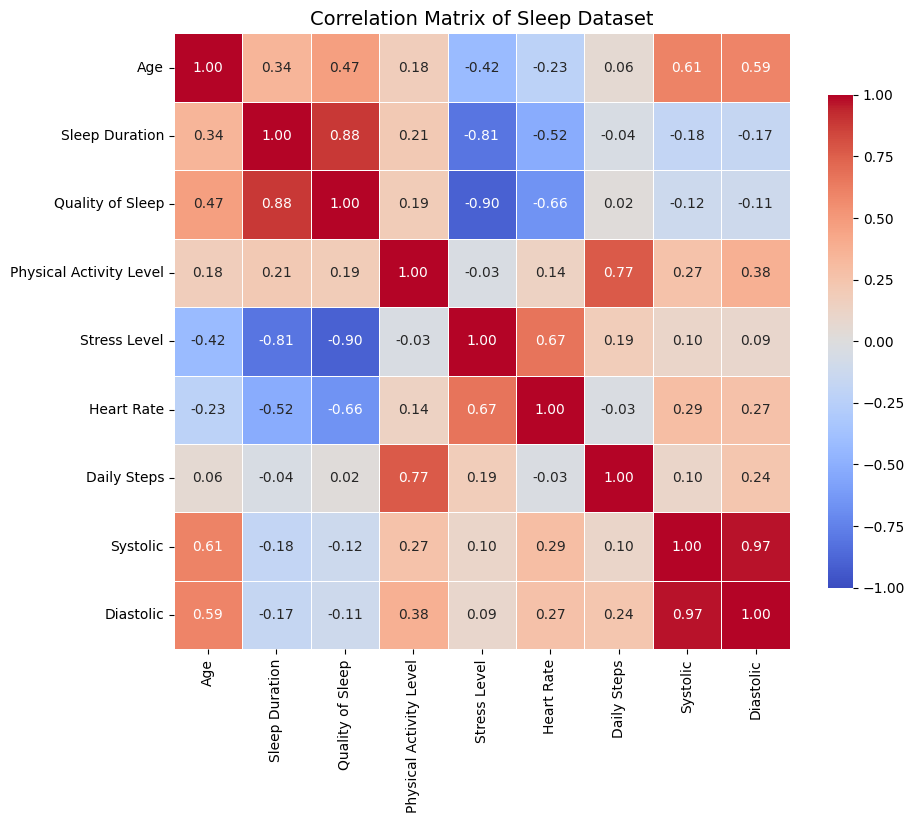

In [109]:
# Analyze correlations between numerical features to:
# - detect multicollinearity
# - identify strongly related variables
# - support feature selection and engineering decisionscorel = df_ml.select_dtypes(include=["int", "float"])
corel = df_ml.select_dtypes(include=["int", "float"])
correlation_sleep = corel.corr()

plt.figure(figsize=(10, 8))

axis_corr = sns.heatmap(
    correlation_sleep,
    vmin=-1, vmax=1, center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Sleep Dataset", fontsize=14)

plt.show()

In [110]:
# Split dataset into features (X) and target variable (y)
X = df_ml.drop(["Quality of Sleep", "Sleep Disorder"], axis=1)
y_disorder= df_ml["Sleep Disorder"]


In [111]:
# Split data into training and test sets (80/20)
# random_state ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(X, y_disorder, test_size=0.2, random_state=42)

In [112]:
# Separate features by data type for preprocessing
categorical_columns = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numerical_columns = X_train.select_dtypes(include=["int", "float"]).columns.tolist()

# Preprocessing pipeline:
# - numerical features: handle missing values and scale data
# - categorical features: handle missing values and encode categories
preprocessing = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),  
        ("scaler", StandardScaler())
    ]), numerical_columns),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),  
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]), categorical_columns)
])

In [113]:
# Define candidate classification models to evaluate performance on Sleep Disorder prediction
# Using a mix of linear, ensemble, distance-based, and gradient boosting methods
models = (
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(n_estimators=100)),
    ("SVM", SVC()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("XGBoost", XGBClassifier())
)

In [114]:
# Encode target labels from strings to integers for model training
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Iterate over defined models, fit pipelines, and evaluate performance
# Pipeline ensures preprocessing + model training is applied consistently
for name, model in models:
    pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train_enc)
    y_pred = pipeline.predict(X_test)
    y_pred_labels = le.inverse_transform(y_pred)
    score = accuracy_score(y_test, y_pred_labels)
    print(f"Classification Report for {model}:\n")
    print(classification_report(y_test, y_pred_labels))

Classification Report for LogisticRegression(max_iter=1000):

              precision    recall  f1-score   support

    Insomnia       0.74      0.88      0.80        16
        None       0.95      0.95      0.95        43
 Sleep Apnea       0.92      0.75      0.83        16

    accuracy                           0.89        75
   macro avg       0.87      0.86      0.86        75
weighted avg       0.90      0.89      0.89        75

Classification Report for RandomForestClassifier():

              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75

Classification Report for SVC():

              precision    recall  f1-score   support

    Insomnia       0.76      0.81 

In [115]:
# Define hyperparameter grids for GridSearch to fine-tune models

xgboost_params = {
    "model__n_estimators": [103, 105, 107],
    "model__max_depth": [4,5,6],
    "model__learning_rate": [0.02, 0.03, 0.04],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

rand_forest_params = {
    "model__n_estimators": [210,220,230],
    "model__max_depth": [2,3,4],
    "model__min_samples_split": [4,5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

log_reg_params = {
    "model__C": [0.8,1,1.2],
    "model__solver": ["lbfgs"]
}

# Candidate models for fine-tuning based on initial performance:
# - XGBoost: gradient boosting ensemble
# - Random Forest: bagged decision trees
# - Logistic Regression: linear baseline
best_models = (
    ("XGBoost", XGBClassifier()),
    ("Random Forest", RandomForestClassifier(n_estimators=100)),
    ("Logistic Regression", LogisticRegression(max_iter=1000))
)

# Map models to their corresponding hyperparameter grids
param_grid = {
    "XGBoost": xgboost_params,
    "Random Forest": rand_forest_params,
    "Logistic Regression": log_reg_params
}

In [116]:
# Hyperparameter tuning using GridSearchCV with 5-fold cross-validation
# Steps:
# 1. Fit pipeline (preprocessing + model) on training data
# 2. Search for best parameters defined in param_grid
# 3. Predict on test data and evaluate accuracy and classification metrics
best_estimators = {}

for name, model in best_models:
    
    # Build pipeline: preprocessing + model
    pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])
    
    # GridSearchCV setup
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid[name],  # model-specific hyperparameters
        cv=5,                         # 5-fold cross-validation
        refit=True,                   # refit on the entire training set with best params
        verbose=3,
        n_jobs=-1                     # use all cores for parallel processing
    )
    
    # Fit GridSearch on training data
    grid.fit(X_train, y_train_enc)
    best_estimators[name] = grid.best_estimator_
    # Predict on test set
    y_pred = grid.predict(X_test)
    
    # Convert encoded predictions back to original labels
    y_pred_labels = le.inverse_transform(y_pred)
    
    # Compute and display accuracy
    score = accuracy_score(y_test, y_pred_labels)
    print(f"{name} test accuracy: {score:.3f}")
    
    # Display best hyperparameters
    print(f"Best parameters for {name}: {grid.best_params_}\n")
    
    # Display full classification report
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred_labels))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
XGBoost test accuracy: 0.907
Best parameters for XGBoost: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.04, 'model__max_depth': 4, 'model__n_estimators': 103, 'model__subsample': 1.0}

Classification Report for XGBoost:

              precision    recall  f1-score   support

    Insomnia       0.81      0.81      0.81        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.91        75
   macro avg       0.88      0.87      0.87        75
weighted avg       0.91      0.91      0.91        75

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Random Forest test accuracy: 0.880
Best parameters for Random Forest: {'model__max_depth': 4, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 220}

Classification Report for Random Forest:

   

                         feature  importance
23  cat__BMI Category_Overweight    0.412532
21      cat__BMI Category_Normal    0.284305
6                  num__Systolic    0.080474
7                 num__Diastolic    0.050637
2   num__Physical Activity Level    0.050243
5               num__Daily Steps    0.025935
22       cat__BMI Category_Obese    0.020014
4                num__Heart Rate    0.016659
18     cat__Occupation_Scientist    0.011660
13        cat__Occupation_Lawyer    0.008854


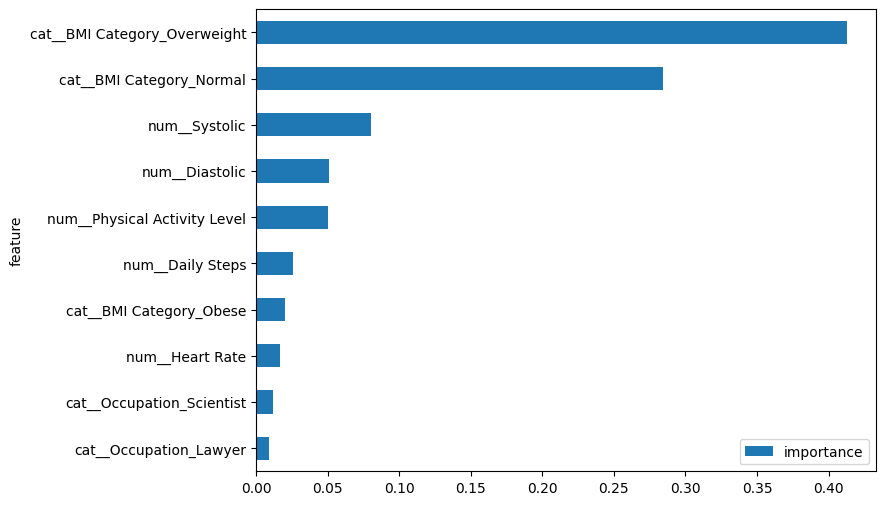

                         feature  importance
21      cat__BMI Category_Normal    0.151845
6                  num__Systolic    0.147711
7                 num__Diastolic    0.123785
23  cat__BMI Category_Overweight    0.111357
15         cat__Occupation_Nurse    0.075744
1            num__Sleep Duration    0.066240
0                       num__Age    0.060197
5               num__Daily Steps    0.058108
2   num__Physical Activity Level    0.054760
3              num__Stress Level    0.044509


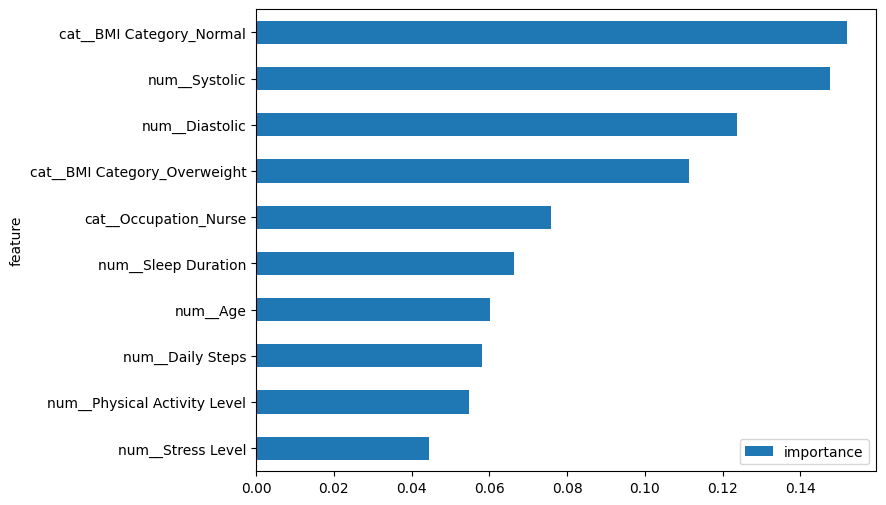

In [117]:
xGBoost_importances = best_estimators["XGBoost"].named_steps["model"].feature_importances_
xGBoost_feature_names = best_estimators["XGBoost"].named_steps["preprocessing"].get_feature_names_out()
xGBoost_feature_importance_df = pd.DataFrame({
    "feature": xGBoost_feature_names,
    "importance": xGBoost_importances
})
xGBoost_feature_importance_df = xGBoost_feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(xGBoost_feature_importance_df.head(10))
xGBoost_feature_importance_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.show()

forest_importances = best_estimators["Random Forest"].named_steps["model"].feature_importances_
forest_feature_names = best_estimators["Random Forest"].named_steps["preprocessing"].get_feature_names_out()
forest_feature_importance_df = pd.DataFrame({
    "feature": forest_feature_names,
    "importance": forest_importances
})
forest_feature_importance_df = forest_feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(forest_feature_importance_df.head(10))
forest_feature_importance_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.show()

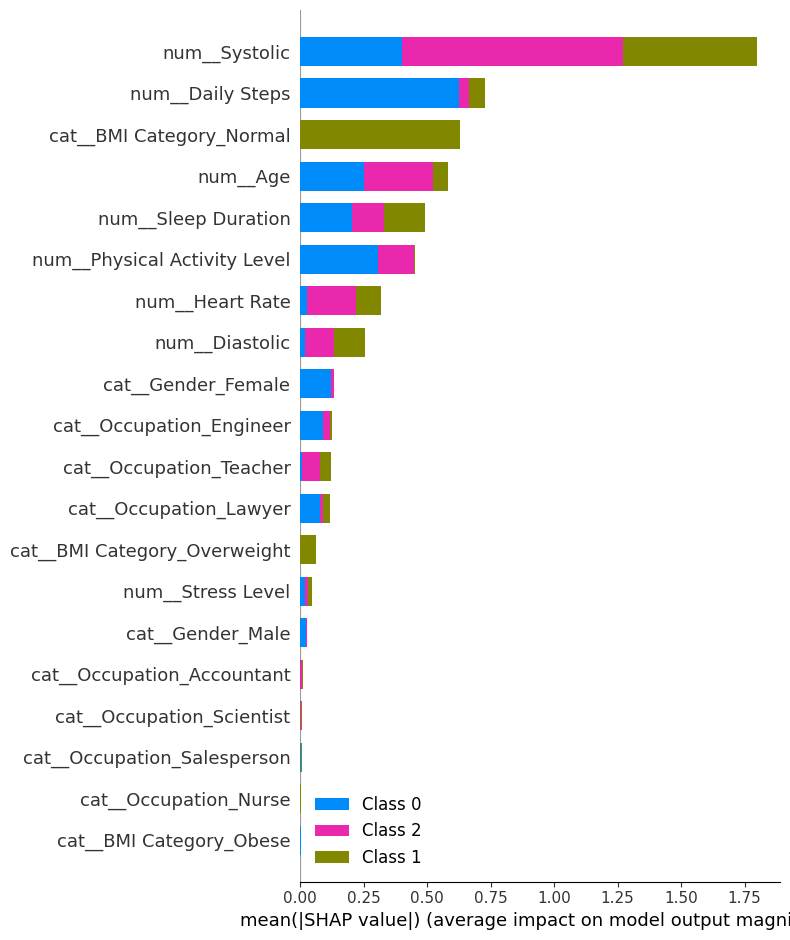

In [118]:
explainer = shap.TreeExplainer(best_estimators["XGBoost"].named_steps["model"])
preprocessor = best_estimators["XGBoost"].named_steps["preprocessing"]
X_test_transformed = preprocessor.transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=xGBoost_feature_names, plot_type="bar")


In [119]:
y_pred = best_estimators["XGBoost"].predict(X_test)
wrong_idx = np.where(y_test_enc != y_pred)[0]
print(wrong_idx)
i = wrong_idx[0]
X_wrong = X_test.iloc[[i]]
print(X_wrong)
true_label = le.inverse_transform([y_test_enc[i]])[0]
pred_label = le.inverse_transform([y_pred[i]])[0]

print(f"Rekord {i} → przewidziano: {pred_label}, prawdziwa etykieta: {true_label}")


[15 40 42 43 48 53 70]
     Gender  Age Occupation  Sleep Duration  Physical Activity Level  \
278  Female   50      Nurse             6.1                       90   

     Stress Level BMI Category  Heart Rate  Daily Steps  Systolic  Diastolic  
278             8   Overweight          75        10000       140         95  
Rekord 15 → przewidziano: Sleep Apnea, prawdziwa etykieta: Insomnia


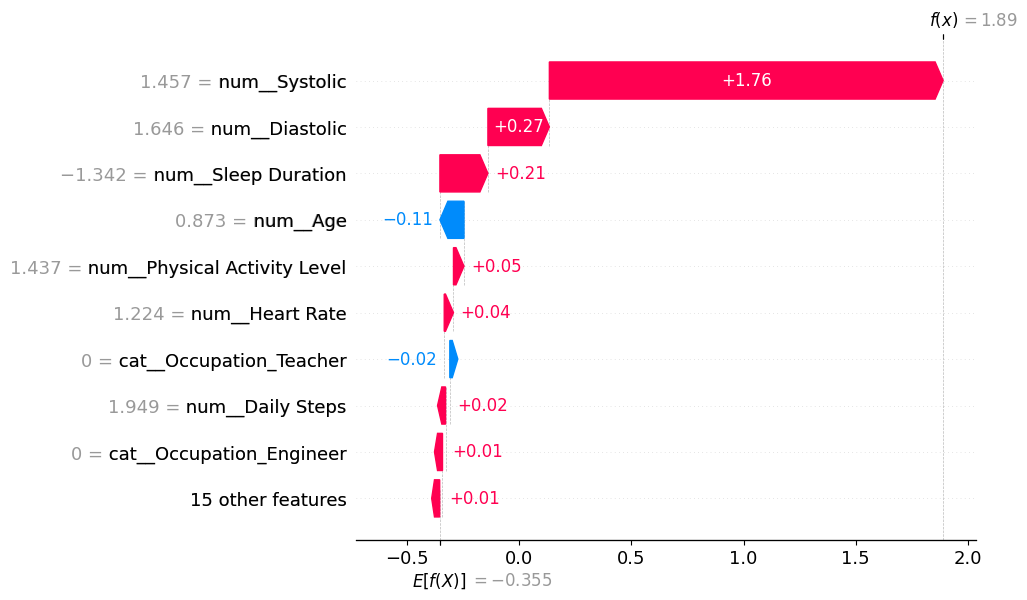

In [120]:
explainer = shap.TreeExplainer(best_estimators["XGBoost"].named_steps["model"])
shap_exp = explainer(X_test_transformed)  # zwraca obiekt shap.Explanation
shap_exp.feature_names = xGBoost_feature_names
             # pierwszy błędny rekord
class_idx = y_pred[i]        # przewidziana klasa
shap.plots.waterfall(shap_exp[i, :, class_idx])

1. Rekord 15 → przewidziano: Sleep Apnea, prawdziwa etykieta: Insomnia


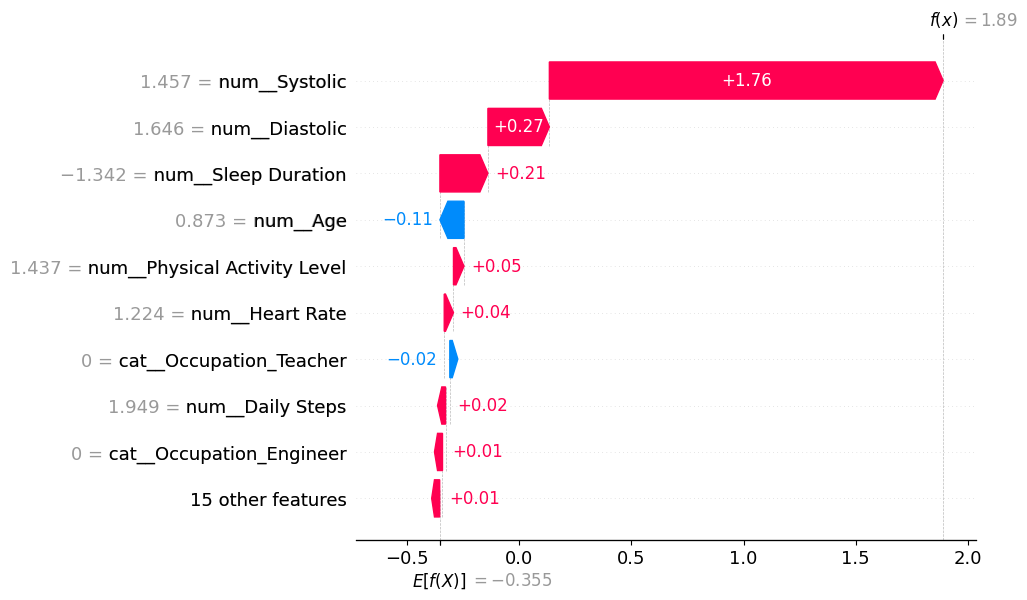

2. Rekord 40 → przewidziano: Insomnia, prawdziwa etykieta: None


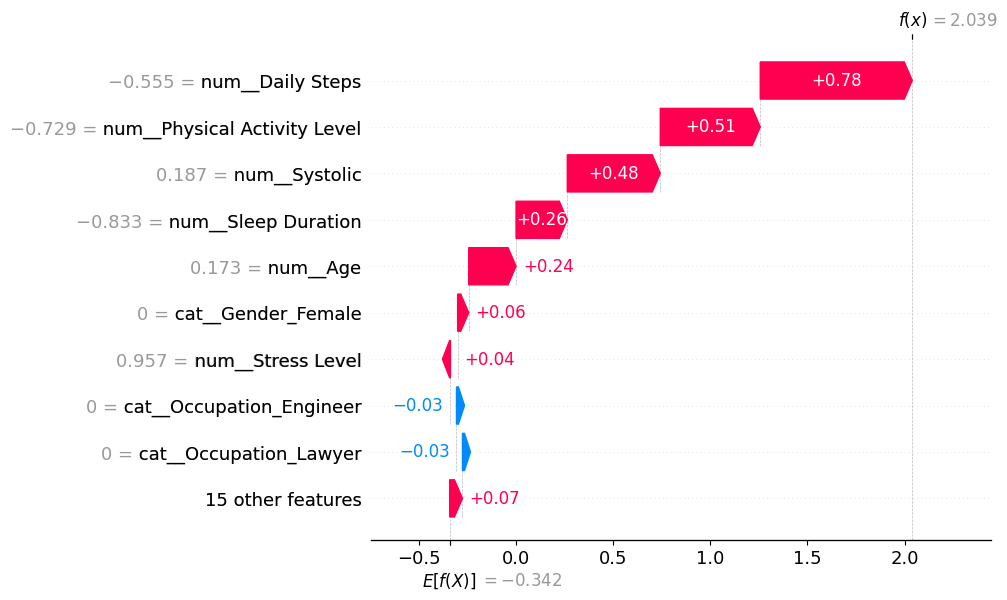

3. Rekord 42 → przewidziano: Insomnia, prawdziwa etykieta: Sleep Apnea


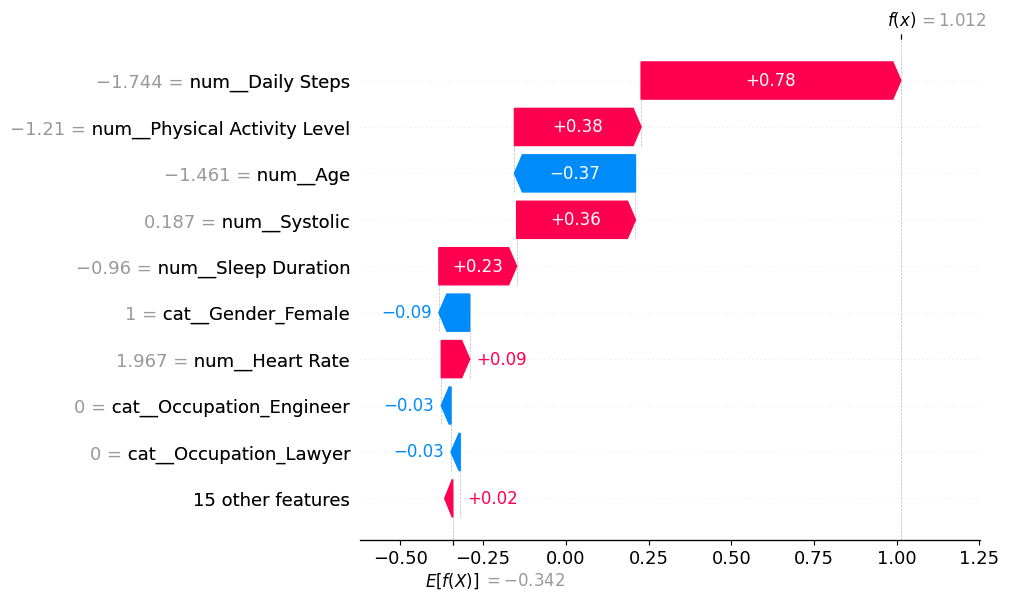

4. Rekord 43 → przewidziano: Insomnia, prawdziwa etykieta: Sleep Apnea


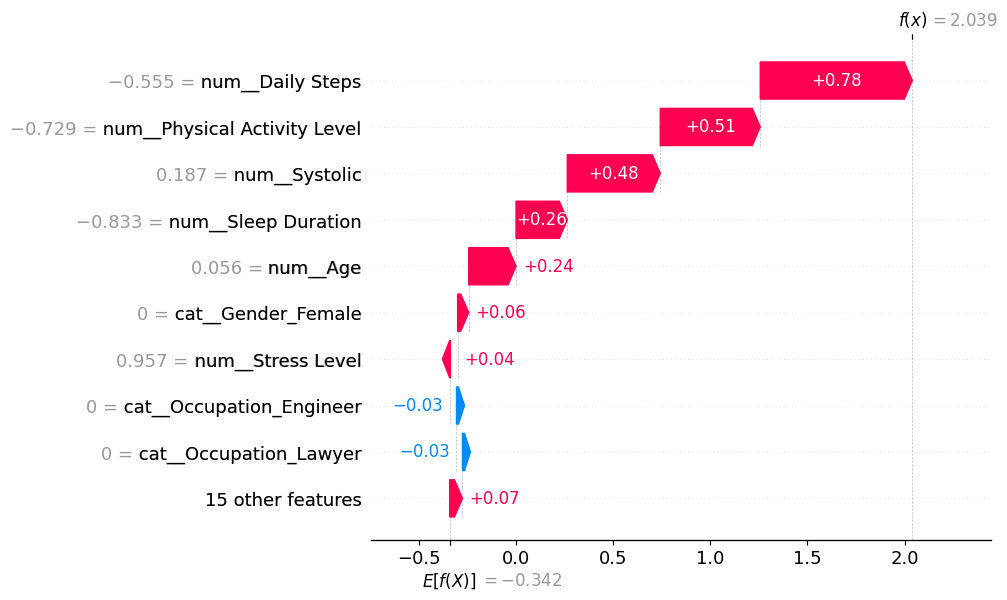

5. Rekord 48 → przewidziano: Sleep Apnea, prawdziwa etykieta: Insomnia


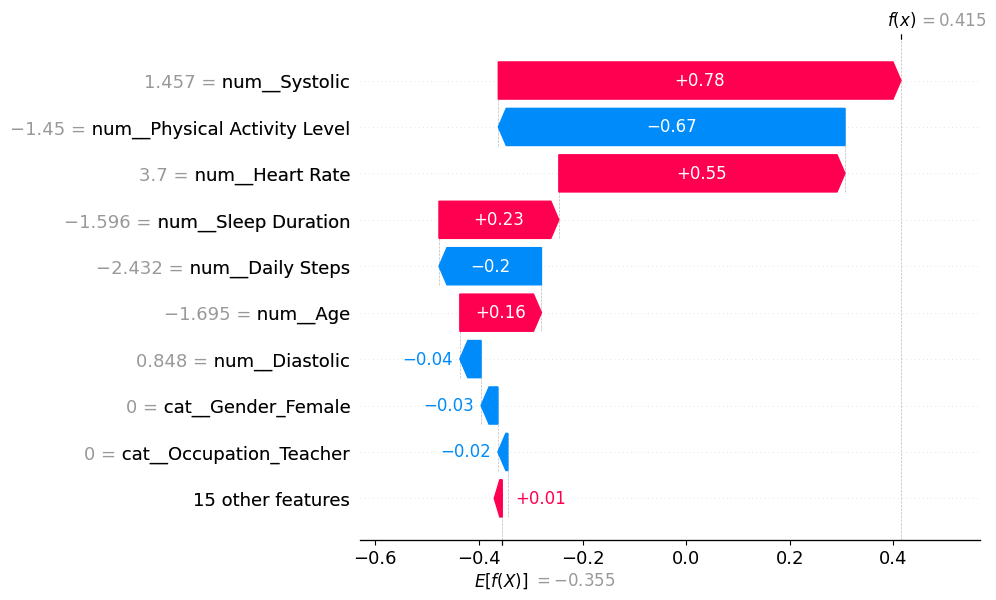

In [121]:
# przewidywania i błędne indeksy
y_pred = best_estimators["XGBoost"].predict(X_test)
wrong_idx = np.where(y_test_enc != y_pred)[0]

# explainer dla modelu XGBoost
explainer = shap.TreeExplainer(best_estimators["XGBoost"].named_steps["model"])
X_test_transformed = pipeline.named_steps["preprocessing"].transform(X_test)
shap_exp = explainer(X_test_transformed)  # zwraca obiekt shap.Explanation
shap_exp.feature_names = xGBoost_feature_names

# petla po pierwszych 5 błędnych rekordach
for rank, i in enumerate(wrong_idx[:5], start=1):
    X_wrong = X_test.iloc[[i]]
    true_label = le.inverse_transform([y_test_enc[i]])[0]
    pred_label = le.inverse_transform([y_pred[i]])[0]

    print(f"{rank}. Rekord {i} → przewidziano: {pred_label}, prawdziwa etykieta: {true_label}")

    # waterfall plot dla konkretnego rekordu

    class_idx = y_pred[i]  # przewidziana klasa
    shap.plots.waterfall(shap_exp[i, :, class_idx])
    

In [122]:
print(df_ml[["BMI Category", "Sleep Disorder"]])
pd.crosstab(df_ml["BMI Category"], df_ml["Sleep Disorder"])
#pd.crosstab(df_ml["BMI Category"], df_ml["Sleep Disorder"], normalize="index") * 100

    BMI Category Sleep Disorder
0     Overweight           None
1         Normal           None
2         Normal           None
3          Obese    Sleep Apnea
4          Obese    Sleep Apnea
..           ...            ...
369   Overweight    Sleep Apnea
370   Overweight    Sleep Apnea
371   Overweight    Sleep Apnea
372   Overweight    Sleep Apnea
373   Overweight    Sleep Apnea

[374 rows x 2 columns]


Sleep Disorder,Insomnia,None,Sleep Apnea
BMI Category,,,
Normal,9,200,7
Obese,4,0,6
Overweight,64,19,65


                  Systolic  Diastolic  Heart Rate  Physical Activity Level  \
Sleep Disorder                                                               
Insomnia        132.038961  86.857143   70.467532                46.818182   
None            124.045662  81.000000   69.018265                57.949772   
Sleep Apnea     137.769231  92.717949   73.089744                74.794872   

                Daily Steps  Sleep Duration  
Sleep Disorder                               
Insomnia        5901.298701        6.589610  
None            6852.968037        7.358447  
Sleep Apnea     7619.230769        7.032051  


<Axes: xlabel='Sleep Disorder', ylabel='Systolic'>

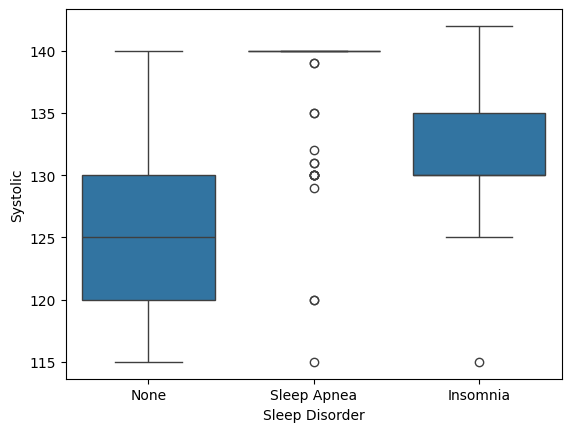

In [123]:
print(df_ml.groupby("Sleep Disorder")[["Systolic", "Diastolic", "Heart Rate", "Physical Activity Level", "Daily Steps", "Sleep Duration"]].mean())
sns.boxplot(x="Sleep Disorder", y="Systolic", data=df_ml)

<Axes: xlabel='Systolic', ylabel='BMI Category'>

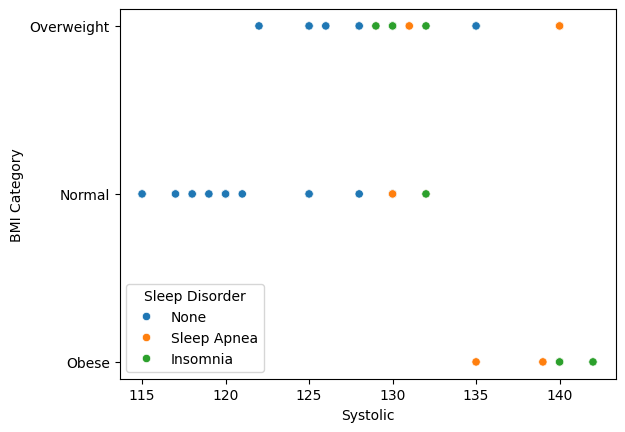

In [124]:
sns.scatterplot(x="Systolic", y="BMI Category", hue="Sleep Disorder", data=df_ml)

In [125]:
joblib.dump(best_estimators["XGBoost"], "xgboost_pipeline.pkl")

['xgboost_pipeline.pkl']

In [126]:


#df_ml["BP_HR"] = df_ml["Systolic"] * df_ml["Heart Rate"]
#df_ml["Sleep_Deficit"] = 7.5 - df_ml["Sleep Duration"]
#df_ml["Sleep_Stress"] = df_ml["Sleep Duration"] / df_ml["Stress Level"]
#df_ml["High_Activity_High_BP"] = ((df_ml["Physical Activity Level"] > 60) &
                                  # (df_ml["Systolic"] > 135)).astype(int)
#df_ml["Activity_BP_ratio"] = df_ml["Physical Activity Level"] / (df_ml["Systolic"] + df_ml["Diastolic"])
df_ml["BP_per_Sleep"] = (df_ml["Systolic"] + df_ml["Diastolic"]) / df_ml["Sleep Duration"]
X = df_ml.drop(["Quality of Sleep", "Sleep Disorder"], axis=1)
y_disorder= df_ml["Sleep Disorder"]
X_train, X_test, y_train, y_test = train_test_split(X, y_disorder, test_size=0.2, random_state=42)
categorical_columns = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numerical_columns = X_train.select_dtypes(include=["int", "float"]).columns.tolist()

preprocessing = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),  # przyszłościowo
        ("scaler", StandardScaler())
    ]), numerical_columns),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),  # dla kategorycznych
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]), categorical_columns)
])
models = (
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(n_estimators=100)),
    ("SVM", SVC()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("XGBoost", XGBClassifier())
)

In [127]:
# label encoding dla targetu
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# iteracja po tuplecie modeli
for name, model in models:
    pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train_enc)
    y_pred = pipeline.predict(X_test)
    y_pred_labels = le.inverse_transform(y_pred)
    score = accuracy_score(y_test, y_pred_labels)
    print(f"{name} test accuracy: {score:.3f}")
    print(f"✅ Best parameters for {name}: {grid.best_params_}\n")
    print(f"Classification Report for {model}:\n")
    print(classification_report(y_test, y_pred_labels))

Logistic Regression test accuracy: 0.907
✅ Best parameters for Logistic Regression: {'model__C': 1, 'model__solver': 'lbfgs'}

Classification Report for LogisticRegression(max_iter=1000):

              precision    recall  f1-score   support

    Insomnia       0.78      0.88      0.82        16
        None       0.95      0.95      0.95        43
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.91        75
   macro avg       0.89      0.88      0.88        75
weighted avg       0.91      0.91      0.91        75

Random Forest test accuracy: 0.880
✅ Best parameters for Random Forest: {'model__C': 1, 'model__solver': 'lbfgs'}

Classification Report for RandomForestClassifier():

              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88 

In [134]:
xgboost_params = {
    "model__n_estimators": [110, 130, 150],
    "model__max_depth": [3,4,5,],
    "model__learning_rate": [0.02, 0.04, 0.06],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

rand_forest_params = {
    "model__n_estimators": [120,150,200],
    "model__max_depth": [2,3,4],
    "model__min_samples_split": [4,5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

log_reg_params = {
    "model__C": [1,2,3],
    "model__solver": ["lbfgs"]
}

best_models = (
    ("XGBoost", XGBClassifier()),
    ("Random Forest", RandomForestClassifier(n_estimators=100)),
    ("Logistic Regression", LogisticRegression(max_iter=1000))
)

param_grid = {
    "XGBoost": xgboost_params,
    "Random Forest": rand_forest_params,
    "Logistic Regression": log_reg_params
}

In [135]:
# Hyperparameter tuning using GridSearchCV with 5-fold cross-validation
# Steps:
# 1. Fit pipeline (preprocessing + model) on training data
# 2. Search for best parameters defined in param_grid
# 3. Predict on test data and evaluate accuracy and classification metrics
best_estimators = {}

for name, model in best_models:
    
    # Build pipeline: preprocessing + model
    pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])
    
    # GridSearchCV setup
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid[name],  # model-specific hyperparameters
        cv=5,                         # 5-fold cross-validation
        refit=True,                   # refit on the entire training set with best params
        verbose=3,
        n_jobs=-1                     # use all cores for parallel processing
    )
    
    # Fit GridSearch on training data
    grid.fit(X_train, y_train_enc)
    best_estimators[name] = grid.best_estimator_
    # Predict on test set
    y_pred = grid.predict(X_test)
    
    # Convert encoded predictions back to original labels
    y_pred_labels = le.inverse_transform(y_pred)
    
    # Compute and display accuracy
    score = accuracy_score(y_test, y_pred_labels)
    print(f"{name} test accuracy: {score:.3f}")
    
    # Display best hyperparameters
    print(f"Best parameters for {name}: {grid.best_params_}\n")
    
    # Display full classification report
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred_labels))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
XGBoost test accuracy: 0.907
Best parameters for XGBoost: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.04, 'model__max_depth': 3, 'model__n_estimators': 110, 'model__subsample': 1.0}

Classification Report for XGBoost:

              precision    recall  f1-score   support

    Insomnia       0.81      0.81      0.81        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.91        75
   macro avg       0.88      0.87      0.87        75
weighted avg       0.91      0.91      0.91        75

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Random Forest test accuracy: 0.880
Best parameters for Random Forest: {'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 200}

Classification Report for Random Forest:

   

                         feature  importance
24  cat__BMI Category_Overweight    0.402759
22      cat__BMI Category_Normal    0.240240
6                  num__Systolic    0.081934
2   num__Physical Activity Level    0.068196
7                 num__Diastolic    0.048125
16         cat__Occupation_Nurse    0.039956
5               num__Daily Steps    0.020294
4                num__Heart Rate    0.017207
23       cat__BMI Category_Obese    0.013747
14        cat__Occupation_Lawyer    0.010791


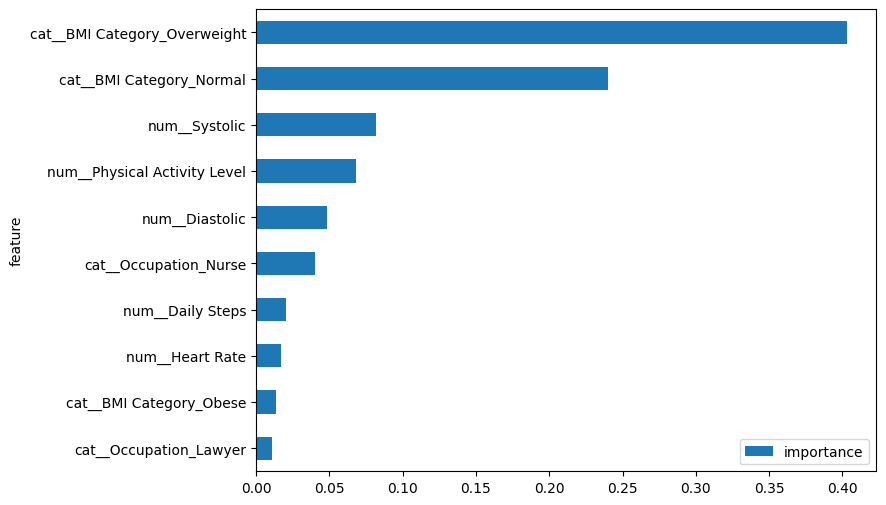

                         feature  importance
22      cat__BMI Category_Normal    0.177910
6                  num__Systolic    0.151632
7                 num__Diastolic    0.107027
24  cat__BMI Category_Overweight    0.106569
8              num__BP_per_Sleep    0.074493
2   num__Physical Activity Level    0.072518
0                       num__Age    0.072283
5               num__Daily Steps    0.047922
16         cat__Occupation_Nurse    0.044365
4                num__Heart Rate    0.039730


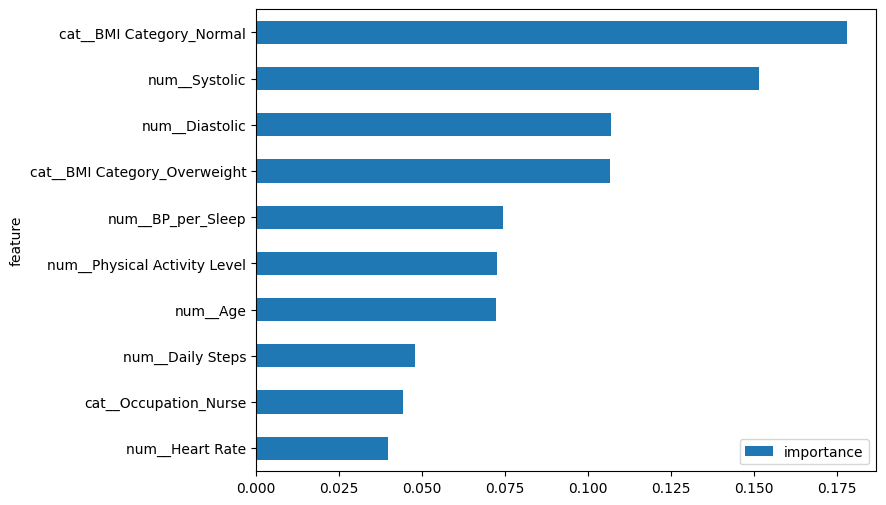

In [136]:
xGBoost_importances = best_estimators["XGBoost"].named_steps["model"].feature_importances_
forest_importances = best_estimators["Random Forest"].named_steps["model"].feature_importances_
xGBoost_feature_names = best_estimators["XGBoost"].named_steps["preprocessing"].get_feature_names_out()
xGBoost_feature_importance_df = pd.DataFrame({
    "feature": xGBoost_feature_names,
    "importance": xGBoost_importances
})
xGBoost_feature_importance_df = xGBoost_feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(xGBoost_feature_importance_df.head(10))
xGBoost_feature_importance_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.show()

forest_importances = best_estimators["Random Forest"].named_steps["model"].feature_importances_
forest_feature_names = best_estimators["Random Forest"].named_steps["preprocessing"].get_feature_names_out()
forest_feature_importance_df = pd.DataFrame({
    "feature": forest_feature_names,
    "importance": forest_importances
})
forest_feature_importance_df = forest_feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(forest_feature_importance_df.head(10))
forest_feature_importance_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.show()

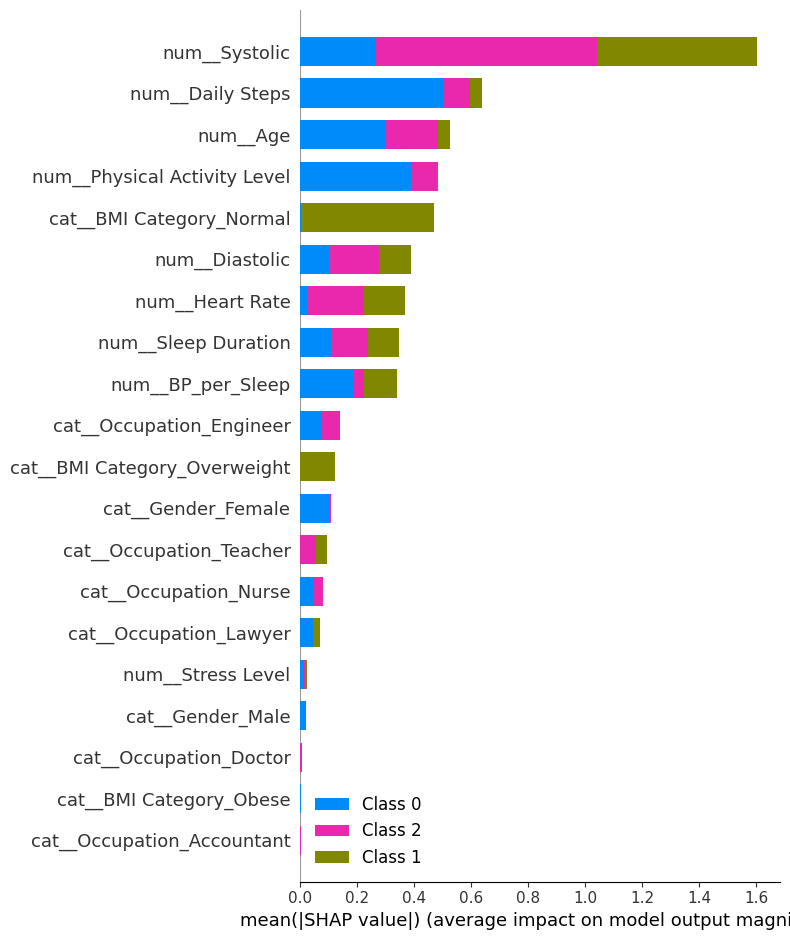

In [137]:
explainer = shap.TreeExplainer(best_estimators["XGBoost"].named_steps["model"])
preprocessor = best_estimators["XGBoost"].named_steps["preprocessing"]
X_test_transformed = preprocessor.transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=xGBoost_feature_names, plot_type="bar")


In [65]:
!python test_model.py

Predicted Sleep Disorder: 1
